In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Project_NN/Data/Cleaned.csv")

X = df.drop(columns=["price_usd_log"]).values
y = df["price_usd_log"].values

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [5]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [6]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
class HousePriceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = HousePriceModel(X_train.shape[1]).to(device)

In [9]:
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8
)

In [10]:
epochs = 200

train_losses = []
val_losses = []

best_loss = float('inf')
patience = 20
counter = 0

In [11]:
epochs = 200

train_losses = []
val_losses = []

best_loss = float('inf')
patience = 20
counter = 0

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # -------- VALIDATION --------
    model.eval()
    val_running_loss = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * features.size(0)

    val_loss = val_running_loss / len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

with torch.no_grad():
    predictions = model(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()

mse = mean_squared_error(y_true, predictions)
mae = mean_absolute_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print("\nFINAL TEST RESULTS")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")


Epoch [1/200] Train Loss: 2.5519 | Val Loss: 0.1603
Epoch [2/200] Train Loss: 0.1775 | Val Loss: 0.1537
Epoch [3/200] Train Loss: 0.1653 | Val Loss: 0.1436
Epoch [4/200] Train Loss: 0.1610 | Val Loss: 0.1440
Epoch [5/200] Train Loss: 0.1566 | Val Loss: 0.1407
Epoch [6/200] Train Loss: 0.1543 | Val Loss: 0.1409
Epoch [7/200] Train Loss: 0.1524 | Val Loss: 0.1405
Epoch [8/200] Train Loss: 0.1512 | Val Loss: 0.1359
Epoch [9/200] Train Loss: 0.1492 | Val Loss: 0.1406
Epoch [10/200] Train Loss: 0.1481 | Val Loss: 0.1324
Epoch [11/200] Train Loss: 0.1483 | Val Loss: 0.1362
Epoch [12/200] Train Loss: 0.1475 | Val Loss: 0.1341
Epoch [13/200] Train Loss: 0.1468 | Val Loss: 0.1320
Epoch [14/200] Train Loss: 0.1463 | Val Loss: 0.1353
Epoch [15/200] Train Loss: 0.1472 | Val Loss: 0.1357
Epoch [16/200] Train Loss: 0.1466 | Val Loss: 0.1325
Epoch [17/200] Train Loss: 0.1459 | Val Loss: 0.1329
Epoch [18/200] Train Loss: 0.1451 | Val Loss: 0.1310
Epoch [19/200] Train Loss: 0.1441 | Val Loss: 0.1295
Ep

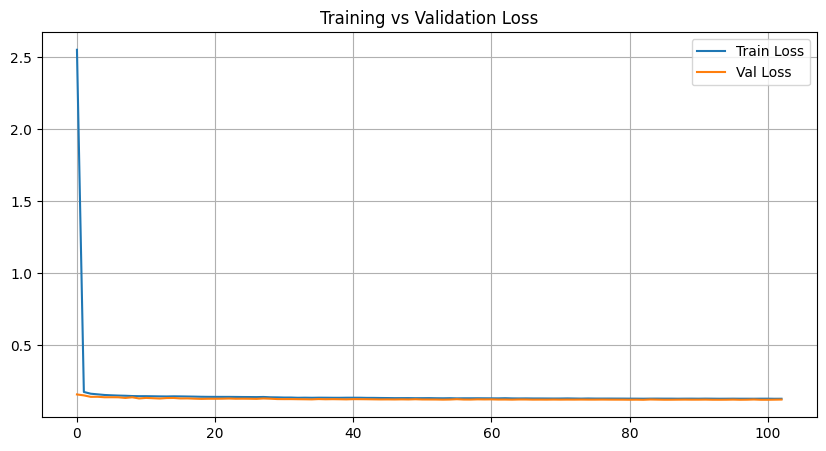

In [12]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()